# E50 · Reaction-diffusion in biology: cell invasion in a scratch assay, and reading a signaling gradient

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Part one: a real **scratch assay** - PC-3 prostate cancer cells counted in 38 columns across a 1.9 mm field at 0, 12, 24, 36 and 48 hours as they close an artificial wound (Jin et al. 2016, *J. Theor. Biol.*; counts as published in the code of Simpson, Murphy & Maclaren 2024). Part two: **simulated** morphogen imaging and FRAP data, with diffusion and clearance rates of the order measured for Nodal/Lefty-type signaling proteins in zebrafish embryos |
| **You will learn** | Reaction-diffusion PDEs as the physics of tissues: **Fisher-KPP** ($u_t = D u_{xx} + \lambda u(1-u)$), travelling waves and their speed $2\sqrt{D\lambda}$ · the **method of lines** in PyTensor: a finite-volume Laplacian with no-flux boundaries, explicit time steps in `scan`, stability ($D\,\Delta t/\Delta x^2 \le 1/2$) · count likelihoods for cell counts and an **estimated carrying capacity** · a **model-misspecification** lesson: leaving out the cells' start-up delay biases the diffusivity fourfold · what is identified: the invasion speed vs $D$ and $\lambda$ separately · **morphogen gradients** (synthesis-diffusion-degradation): exact solutions via the **eigenbasis** of the discrete Laplacian, differentiable in PyMC · why a steady-state gradient identifies only the **decay length** $\sqrt{D/k}$, and how **FRAP** data separate $D$ from $k$ · **positional information**: how precisely a cell can read its position from receptor occupancy, why receptors read best near $K_d$, and the posterior number of distinguishable positions |

## Reaction plus diffusion, in one paragraph

Two processes shape most patterns in living tissue. Things **spread**: cells crawl into empty
space, signaling molecules diffuse away from the cells that secrete them. And things **react**:
cells divide until they are crowded, signaling molecules are bound, taken up and destroyed. A
reaction-diffusion equation writes both down at once, $\partial_t u = D\,\partial_x^2 u + f(u)$,
and its solutions are the fronts, waves and gradients that biologists see down the microscope.
This notebook fits two such models. First, a wound in a sheet of cancer cells closing over two
days: how fast do the cells move and how fast do they divide? Second, a gradient of a secreted
signaling protein that tells cells where they are in an embryo: which measurements pin down its
diffusion and its degradation, and how precisely can a cell read its position from it?

## The plan

**Part one - cell invasion (real data)**
1. The scratch assay
2. Fisher-KPP by the method of lines
3. Two models: with and without a start-up delay
4. What is identified, and the invasion wave

**Part two - a signaling gradient (simulated from literature-scale parameters)**
5. Synthesis, diffusion and degradation, solved exactly
6. An image of the gradient identifies only its length scale
7. FRAP separates diffusion from degradation
8. Positional information: how well can a cell read the gradient?

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import HTML
from matplotlib import animation

from pymc_challenges import data

RANDOM_SEED = 50
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
TIME_COLOURS = ["#1b3a6b", "#2a78d6", "#1baf7a", "#e8b422", "#eb6834"]
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · The scratch assay

A **scratch assay** is the simplest experiment on collective cell migration: grow cells into a
confluent sheet, scratch a wound through it with a pipette tip, and photograph the wound as it
closes. Jin et al. (2016) did this with PC-3 prostate cancer cells and counted the cells in 50 µm
wide columns across the image every 12 hours. A fully packed column holds about 122 cells.

scratch_assay_pc3: Scratch (wound-healing) assay with PC-3 prostate cancer cells: number of cells in each of 38 columns 50 um wide (centres x_um = 25..1875 um) across a 1,900 um field, counted at t_h = 0, 12, 24, 36 and 48 hours after the scratch. A column fully packed holds about 122 cells (packing density 1.7e-3 cells/um^2 x 50 um x 1,430 um).
  source: Jin, Shah, Penington, McCue, Chopin & Simpson (2016), Reproducibility of scratch assays is affected by the initial degree of confluence: experiments, modelling and model selection, Journal of Theoretical Biology 390:136-145; counts as distributed in the code of Simpson, Murphy & Maclaren (2024), Modelling count data with partial differential equation models in biology, Journal of Theoretical Biology 580:111732. TRANSCRIBED from the arrays in that Julia file (the URL is code, not a CSV), so keep the cached file in data/.
  url:    https://raw.githubusercontent.com/ProfMJSimpson/NoiseModels/main/PDE_BinomialNoiseModel.jl
38 columns x 5 

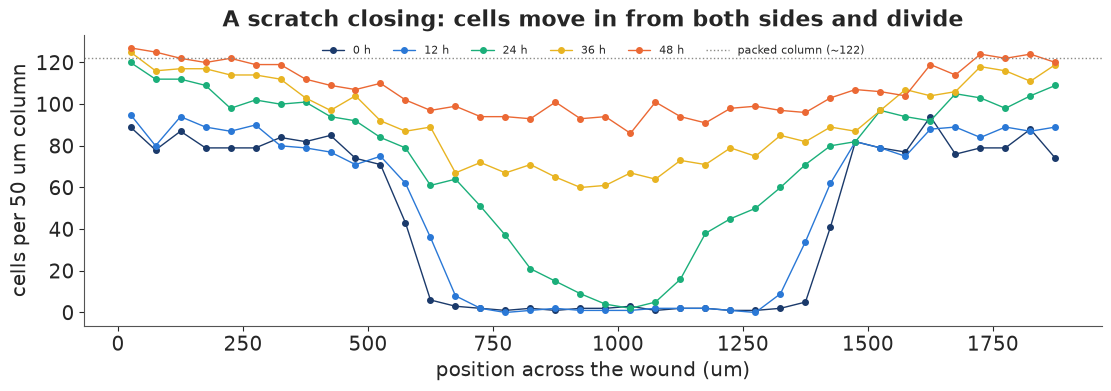

In [2]:
data.describe("scratch_assay_pc3")
assay = data.load("scratch_assay_pc3")
counts = assay.pivot(index="x_um", columns="t_h", values="count")
x_cols = counts.index.to_numpy().astype(float)                 # column centres, um
t_obs = counts.columns.to_numpy().astype(float)                 # 0, 12, 24, 36, 48 h
C = counts.to_numpy().T                                         # (time, column)
print(f"{C.shape[1]} columns x {C.shape[0]} times; counts {C.min()}-{C.max()}; "
      f"total cells {C.sum(axis=1)} at t = {t_obs.astype(int)} h")

fig, ax = plt.subplots(figsize=(11, 3.8))
for i, (t, c) in enumerate(zip(t_obs, TIME_COLOURS)):
    ax.plot(x_cols, C[i], "o-", color=c, ms=4, lw=1, label=f"{t:.0f} h")
ax.axhline(122, color=GREY, ls=":", lw=1, label="packed column (~122)")
ax.set(xlabel="position across the wound (um)", ylabel="cells per 50 um column",
       title="A scratch closing: cells move in from both sides and divide")
ax.legend(fontsize=8, ncols=6);

Two things happen at once: the edges of the wound creep inwards (movement) and the whole sheet
gets denser, from about 80 to about 120 cells per column far from the wound (division). The total
number of cells rises by about half over 48 hours. The wound is also not quite empty at time 0
and not quite symmetric, so we will start the model from the observed initial profile.

## 2 · Fisher-KPP by the method of lines

The classic model is the **Fisher-KPP** equation (Fisher 1937; Kolmogorov, Petrovsky & Piskunov
1937) for the cell density $u(x, t)$ relative to the carrying capacity:

$$\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2} + \lambda\,u\,(1 - u),$$

random movement with diffusivity $D$ (µm² h⁻¹) plus logistic proliferation at rate $\lambda$
(h⁻¹). On an infinite domain its fronts become **travelling waves** with speed
$c = 2\sqrt{D\lambda}$.

To put a PDE into PyMC we use the **method of lines**. Each 50 µm column is a finite volume.
The second derivative becomes a difference of neighbouring columns, with **no-flux** boundaries
at the edges of the image (no cells enter or leave there). Time advances with explicit Euler
steps of $\Delta t = 0.1$ h inside a `pytensor.scan`, 480 steps for 48 hours. Explicit steps are
stable only when $D\,\Delta t/\Delta x^2 \le 1/2$, which here means $D \le 12{,}500$ µm²/h, far
above any value the prior takes seriously. The observed counts are Poisson with mean $K u$,
where $K$ is the carrying capacity in cells per column. It is **estimated**, not fixed at 122,
because the densest columns at 48 h are already above 122 and the cells may pack differently
from the nominal density.

In [3]:
DX, DT = 50.0, 0.1
N_STEPS = int(round(t_obs[-1] / DT))
obs_steps = np.round(t_obs[1:] / DT).astype(int)               # 120, 240, 360, 480
t_grid = np.arange(N_STEPS) * DT
count0 = np.clip(C[0], 0.1, None)                              # observed initial profile (cells)
print(f"{N_STEPS} Euler steps; stability needs D <= {0.5 * DX**2 / DT:,.0f} um^2/h")


def laplacian_noflux(u):
    """Finite-volume second difference with zero-flux boundaries, divided by dx^2."""
    return pt.concatenate([u[1:2] - u[0:1], u[2:] - 2 * u[1:-1] + u[:-2], u[-2:-1] - u[-1:]]) / DX**2


def fisher_kpp_model(delay):
    with pm.Model() as model:
        D = pm.LogNormal("D", np.log(1000), 1.0)              # um^2 / h
        lam = pm.LogNormal("lam", np.log(0.05), 1.0)          # 1 / h
        K = pm.Normal("K", 122, 15)                           # cells per column when packed
        beta = pm.LogNormal("beta", np.log(0.1), 1.0) if delay else pt.constant(0.0)
        pm.Deterministic("wave_speed", 2 * pt.sqrt(D * lam))  # um / h

        def step(t, u, D, lam, beta):
            activity = pt.tanh(beta * t) if delay else 1.0
            return u + DT * activity * (D * laplacian_noflux(u) + lam * u * (1 - u))

        u_init = count0 / K                                         # density relative to capacity
        path = pytensor.scan(step, sequences=[t_grid], outputs_info=[u_init],
                             non_sequences=[D, lam, beta], return_updates=False)
        u_at_obs = pm.Deterministic("u", path[obs_steps - 1])        # (4, 38) at 12..48 h
        pm.Poisson("count", pt.clip(K * u_at_obs, 1e-6, 1e6), observed=C[1:])
    return model

480 Euler steps; stability needs D <= 12,500 um^2/h


Priors: $D \sim$ LogNormal(log 1000, 1), about 100-10,000 µm²/h, the range reported for
mammalian cells in scratch assays; $\lambda \sim$ LogNormal(log 0.05, 1), doubling times from
about 5 hours to several days; $K \sim N(122, 15)$ cells per column.

## 3 · Two models: with and without a start-up delay

Cells that have just been scratched do not immediately behave normally: they recover from the
disturbance before they move and divide at full speed. Following Simpson and coauthors, the
second model multiplies both terms by $\tanh(\beta t)$, which rises from 0 to 1 on a time scale
$1/\beta$. We fit both and compare them with PSIS-LOO over the 152 counts (one term per column
and time).

In [4]:
fits = {}
for name, delay in [("Fisher-KPP", False), ("Fisher-KPP + delay", True)]:
    t0 = time.time()
    with fisher_kpp_model(delay):
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idata, progressbar=False)
    fits[name] = idata
    names = ["D", "lam", "K", "wave_speed"] + (["beta"] if delay else [])
    print(f"{name}: {time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences")
    print(az.summary(idata, var_names=names, round_to=4)[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])
comparison = az.compare({k: v for k, v in fits.items()})
print(comparison[["elpd", "elpd_diff", "dse", "p"]].round(1))
for name, idata in fits.items():
    k_hat = az.loo(idata, pointwise=True).pareto_k.values
    print(f"{name}: {np.sum(k_hat > 0.7)} of {k_hat.size} counts with Pareto k > 0.7")

Fisher-KPP: 14 s, 0 divergences
                mean       sd  eti89_lb  eti89_ub   ess_bulk   r_hat
D           284.0435  49.2344  215.5251  369.0734  1071.4010  1.0015
lam           0.1027   0.0041    0.0960    0.1087  1042.0204  1.0022
K           108.4652   1.4163  106.2810  110.8292  1561.0927  1.0015
wave_speed   10.7465   0.7208    9.6424   11.9261  1140.0193  1.0012


Fisher-KPP + delay: 22 s, 0 divergences
                 mean        sd  eti89_lb   eti89_ub   ess_bulk   r_hat
D           1262.2566  211.4387  969.1712  1618.3115  1013.7401  1.0075
lam            0.1464    0.0172    0.1240     0.1744   908.2136  1.0033
K            113.5526    1.9958  110.3908   116.8478  1579.4772  1.0035
wave_speed    27.1038    3.3122   22.7859    32.5992   856.8578  1.0029
beta           0.0440    0.0070    0.0332     0.0555   830.7099  1.0032


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


                     elpd  elpd_diff   dse     p
Fisher-KPP + delay -540.0        0.0   0.0   5.4
Fisher-KPP         -650.0     -110.0  19.0  16.6
Fisher-KPP: 1 of 152 counts with Pareto k > 0.7


Fisher-KPP + delay: 0 of 152 counts with Pareto k > 0.7


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


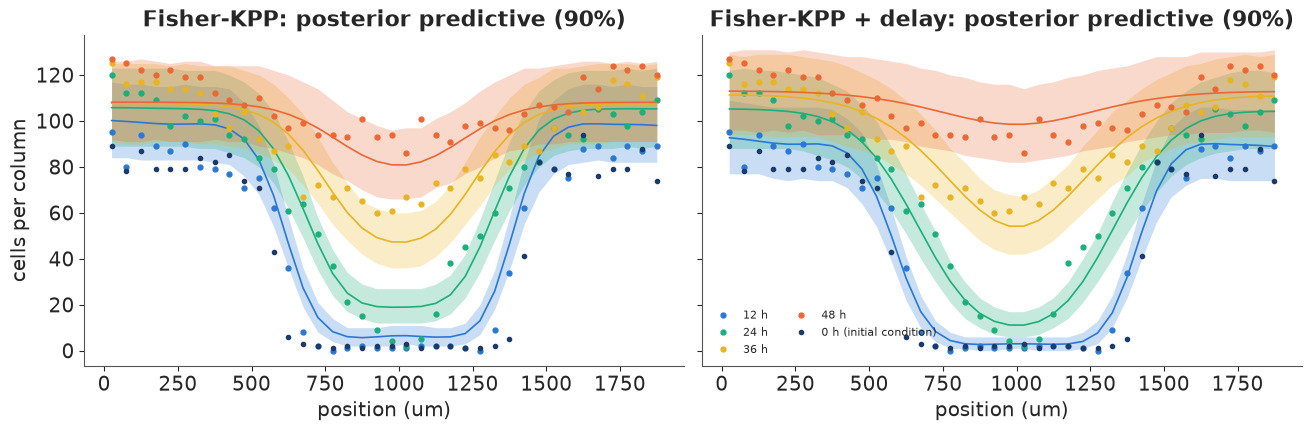

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (name, idata) in zip(axes, fits.items()):
    u_post = idata.posterior["u"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
    K_post = idata.posterior["K"].stack(sample=("chain", "draw")).to_numpy()
    pred = rng.poisson(K_post[:, None, None] * u_post)
    for i, c in enumerate(TIME_COLOURS[1:]):
        lo, hi = np.quantile(pred[:, i], [0.05, 0.95], axis=0)
        ax.fill_between(x_cols, lo, hi, color=c, alpha=0.25, lw=0)
        ax.plot(x_cols, np.median(K_post[:, None] * u_post[:, i], axis=0), color=c, lw=1.2)
        ax.plot(x_cols, C[i + 1], "o", color=c, ms=3.5, label=f"{t_obs[i + 1]:.0f} h")
    ax.plot(x_cols, C[0], "o", color=TIME_COLOURS[0], ms=3, label="0 h (initial condition)")
    ax.set(xlabel="position (um)", title=f"{name}: posterior predictive (90%)")
axes[0].set_ylabel("cells per column")
axes[1].legend(fontsize=8, ncols=2);

The difference is not subtle. **Without the delay**, the model cannot have the wound nearly
unchanged at 12 hours *and* almost closed at 48 hours, and its compromise misses the
12-hour and 24-hour profiles. With the delay the predictive bands follow every profile, and LOO
prefers it by a margin many times its standard error. (The LOO warning comes from a single count
with Pareto $\hat k > 0.7$ in the model *without* the delay - an observation that model fits
badly, as expected; the delay model has none.)

Both models under-predict the densest columns far from the wound at 48 hours (up to 127 cells,
against a fitted capacity of about 114): the sheet keeps packing where logistic growth with one
capacity says it should have stopped. That is a real limitation of the model, not of the fit.

Now look at the parameters. The two models disagree about the diffusivity by a factor of
about four and a half ($D \approx 280$ vs $\approx 1{,}260$ µm²/h). Leaving out the slow start does not
just worsen the fit; it **biases the estimate of cell motility**. This is the pattern Simpson
and colleagues warn about in scratch-assay analysis: a parameter estimate is only as good as the
model around it. The posterior intervals of the misspecified model are narrow and wrong.

Compared with the maximum-likelihood analysis of the same data by Simpson, Murphy & Maclaren
(binomial counts with the capacity *fixed* at 122 cells), our $D$ and $\beta$ fall in the same
region ($D$ about 970-1,620 µm²/h and $\beta$ about 0.03-0.06 h⁻¹, 89% intervals), while
$\lambda$ comes out higher. That is because the capacity is estimated here at about 114
cells, not fixed at 122: reaching a lower ceiling in the same time needs faster
growth. The **carrying capacity and the growth rate trade off**, and fixing one moves the other.

## 4 · What is identified, and the invasion wave

posterior coefficient of variation: {'D': np.float64(0.168), 'lambda': np.float64(0.118), 'K': np.float64(0.018), 'beta': np.float64(0.158), 'wave speed': np.float64(0.122)}
correlation of log D and log lambda: 0.41; of lambda and K: -0.46; of lambda and beta: -0.81
wave speed 2 sqrt(D lambda): 27 um/h (90%: 23-33); doubling time ln2/lambda: 4.8 h; start-up time 1/beta: 23 h


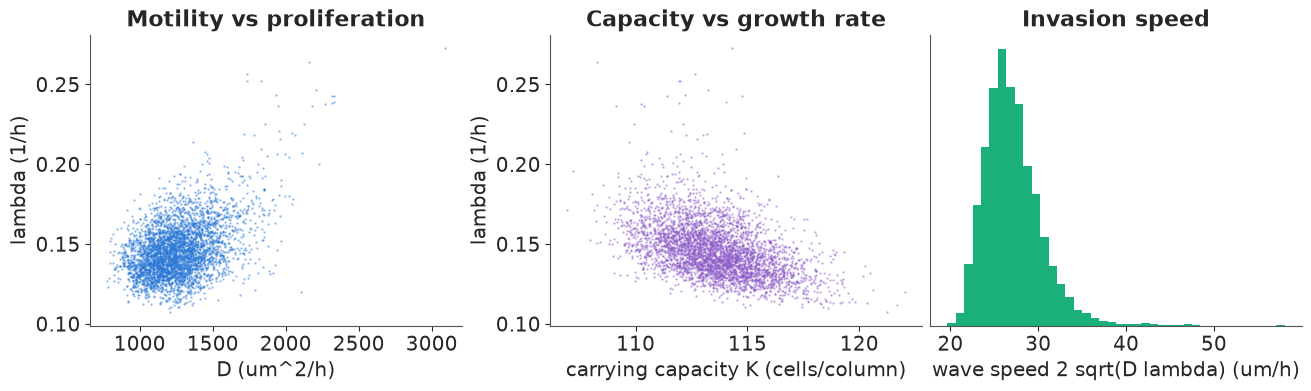

In [6]:
post = fits["Fisher-KPP + delay"].posterior
D_s, lam_s, K_s = (post[v].stack(sample=("chain", "draw")).to_numpy() for v in ["D", "lam", "K"])
beta_s = post["beta"].stack(sample=("chain", "draw")).to_numpy()
speed_s = 2 * np.sqrt(D_s * lam_s)
cv = {name: np.std(v) / np.mean(v) for name, v in
      [("D", D_s), ("lambda", lam_s), ("K", K_s), ("beta", beta_s), ("wave speed", speed_s)]}
print("posterior coefficient of variation:", {k: round(v, 3) for k, v in cv.items()})
print(f"correlation of log D and log lambda: {np.corrcoef(np.log(D_s), np.log(lam_s))[0, 1]:.2f}; "
      f"of lambda and K: {np.corrcoef(lam_s, K_s)[0, 1]:.2f}; of lambda and beta: {np.corrcoef(lam_s, beta_s)[0, 1]:.2f}")
print(f"wave speed 2 sqrt(D lambda): {np.median(speed_s):.0f} um/h "
      f"(90%: {np.quantile(speed_s, 0.05):.0f}-{np.quantile(speed_s, 0.95):.0f}); "
      f"doubling time ln2/lambda: {np.median(np.log(2) / lam_s):.1f} h; "
      f"start-up time 1/beta: {np.median(1 / beta_s):.0f} h")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(D_s, lam_s, ".", color=BLUE, ms=1.5, alpha=0.4)
axes[0].set(xlabel="D (um^2/h)", ylabel="lambda (1/h)", title="Motility vs proliferation")
axes[1].plot(K_s, lam_s, ".", color=PURPLE, ms=1.5, alpha=0.4)
axes[1].set(xlabel="carrying capacity K (cells/column)", ylabel="lambda (1/h)", title="Capacity vs growth rate")
axes[2].hist(speed_s, bins=40, color=AQUA)
axes[2].set(xlabel="wave speed 2 sqrt(D lambda) (um/h)", yticks=[], title="Invasion speed");

In an idealised travelling-wave experiment only the wave speed $2\sqrt{D\lambda}$ would be
identified. Here the data do better: the sheet visibly densifies away from the wound, which
measures $\lambda$ on its own, so $D$ and $\lambda$ are only moderately correlated (0.41 on the
log scale) and both are estimated to within 12-17%. The wave speed, about 27 µm/h, is determined
better than $D$ and about as well as $\lambda$. The strongest trade-offs involve the other
parameters: **a higher growth rate goes with a lower ceiling** ($\lambda$ and $K$, correlation
-0.46) **and, above all, with a slower start** ($\lambda$ and $\beta$, -0.81): cells that start
late must then grow fast to catch up. The low-density doubling time $\ln 2/\lambda$ of about 5
hours is fast. Because $\lambda$ trades off against the start-up delay and the capacity,
it should be read as a model parameter, not a direct measurement of the cell cycle. Separating
these would take a different experiment, for example cell-cycle imaging or blocking division
with mitomycin C. Part two meets the same problem in signaling, and solves it with a second kind
of measurement.

### The wound closing, hour by hour

The fit only ever sees five snapshots. The model, though, describes every moment in between, so we
can replay the assay: the animation runs the delay model forward in NumPy for 200 posterior draws
and shows the median cell density and its 90% band (the uncertainty in the *mean* density, without
the Poisson counting noise) every hour, with the counts overlaid when the clock passes an
observation time. Watch for the long pause at the start (the $\tanh(\beta t)$ delay), then the
two fronts moving in at the wave speed while the sheet behind them densifies.

In [7]:
def kpp_paths(D, lam, K, beta, every=10):
    """Explicit Euler paths of the delay model for vectors of draws; returns (frames, draws, columns)."""
    u = (count0[None, :] / K[:, None]).copy()
    frames = [u.copy()]
    for i, t in enumerate(t_grid):
        lap = np.concatenate([u[:, 1:2] - u[:, :1], u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2],
                              u[:, -2:-1] - u[:, -1:]], axis=1) / DX**2
        u = u + DT * np.tanh(beta[:, None] * t) * (D[:, None] * lap + lam[:, None] * u * (1 - u))
        if (i + 1) % every == 0:
            frames.append(u.copy())
    return np.array(frames) * K[None, :, None]


pick_anim = rng.choice(D_s.size, 200, replace=False)
dens = kpp_paths(D_s[pick_anim], lam_s[pick_anim], K_s[pick_anim], beta_s[pick_anim])   # (49, 200, 38)
hours = np.arange(dens.shape[0]) * 10 * DT
lo_b, med_b, hi_b = np.quantile(dens, [0.05, 0.5, 0.95], axis=1)

fig, ax = plt.subplots(figsize=(8, 4), dpi=72)
band = ax.fill_between(x_cols, lo_b[0], hi_b[0], color=BLUE, alpha=0.3, lw=0)
(line,) = ax.plot(x_cols, med_b[0], color=BLUE, lw=2, label="model: median and 90% band")
(pts,) = ax.plot(x_cols, C[0], "o", color=INK, ms=4, label="counts at the last observation")
ax.set(xlabel="position (um)", ylabel="cells per column", ylim=(0, 140))
ax.legend(fontsize=8, loc="lower left")
title = ax.set_title("")
plt.close(fig)


def update(i):
    global band
    band.remove()
    band = ax.fill_between(x_cols, lo_b[i], hi_b[i], color=BLUE, alpha=0.3, lw=0)
    line.set_ydata(med_b[i])
    j = int(np.searchsorted(t_obs, hours[i] + 1e-9)) - 1                # last observation passed
    pts.set_ydata(C[j])
    pts.set_alpha(1.0 if np.isclose(hours[i], t_obs[j]) else 0.25)
    title.set_text(f"t = {hours[i]:4.1f} h  (counts shown: {t_obs[j]:.0f} h)")
    return line, pts, title


anim = animation.FuncAnimation(fig, update, frames=len(hours), interval=150)
HTML(anim.to_jshtml(default_mode="once"))

## 5 · Synthesis, diffusion and degradation, solved exactly

Embryos are patterned by **morphogens**: signaling proteins secreted by a group of cells that
spread through the tissue and are cleared as they go. Neighbouring cells see a high concentration
and distant cells a low one, and they switch on different genes accordingly. The simplest model
is **synthesis-diffusion-degradation** (SDD): production at rate $s$ in a source region,
diffusion with coefficient $D$, first-order clearance at rate $k$,

$$\frac{\partial c}{\partial t} = D\,\frac{\partial^2 c}{\partial x^2} - k\,c + s\,\mathbb{1}_{\text{source}}(x).$$

Away from the source the steady state decays over the **decay length** $\ell = \sqrt{D/k}$:
$c \propto e^{-x/\ell}$ on a long field, and $c \propto \cosh((L - x)/\ell)$ when a no-flux
boundary at $x = L$ stops the molecules (the gradient flattens near the far wall).

We use numbers of the order measured for the Nodal/Lefty family in zebrafish (Müller et al.
2012, *Science*): diffusion coefficients of a few µm²/s, and clearance with a half-life of about
an hour. The data here are **simulated** - $D = 2$ µm²/s, $k = 2 \times 10^{-4}$ s⁻¹ (half-life
58 min), $\ell = 100$ µm - on a 300 µm field with a 15 µm source at the left edge. Simulating
lets us check what each kind of measurement can recover.

The equation is **linear**, so it has an exact solution. On the grid, $dc/dt = A c + s$ with
$A = D\,L - k\,I$, where $L$ is the no-flux discrete Laplacian. $L$ is fixed, so we
diagonalise it once, $L = V\,\mathrm{diag}(\mu)\,V^\top$, and then for any $D$ and $k$

$$c_{ss} = -V\,\mathrm{diag}\!\Big(\frac{1}{D\mu_i - k}\Big) V^\top s, \qquad
  c(t) = c_{ss} + V\,\mathrm{diag}\big(e^{(D\mu_i - k)t}\big)\,V^\top\,(c(0) - c_{ss}).$$

These are matrix products with a fixed $V$: no time stepping, exact at any time, and
differentiable in PyTensor. (Part one's Fisher-KPP is nonlinear, so it needed `scan`.)

In [8]:
L_FIELD, NX = 300.0, 100
DXS = L_FIELD / NX
xs = (np.arange(NX) + 0.5) * DXS
Lap = np.diag(-2.0 * np.ones(NX)) + np.diag(np.ones(NX - 1), 1) + np.diag(np.ones(NX - 1), -1)
Lap[0, 0] = Lap[-1, -1] = -1.0
Lap /= DXS**2
mu_eig, V_eig = np.linalg.eigh(Lap)                            # mu <= 0
source = (xs < 15).astype(float)
D_TRUE, K_TRUE = 2.0, 2e-4


def sdd_steady(D, k):
    rates = D * mu_eig - k
    return V_eig @ ((V_eig.T @ source) / (-rates))


def frap_recovery(D, k, t, bleach, fraction):
    """Mean concentration in the bleached window over time, relative to its pre-bleach value."""
    rates = D * mu_eig - k
    c_ss = V_eig @ ((V_eig.T @ source) / (-rates))
    c0 = c_ss.copy()
    c0[bleach] *= 1 - fraction
    c_t = c_ss[None, :] + (np.exp(rates[None, :] * t[:, None]) * (V_eig.T @ (c0 - c_ss))[None, :]) @ V_eig.T
    return c_t[:, bleach].mean(1) / c_ss[bleach].mean()


c_true = sdd_steady(D_TRUE, K_TRUE)
ell = np.sqrt(D_TRUE / K_TRUE)
outside = xs > 30
analytic = np.cosh((L_FIELD - xs) / ell)                       # exact shape outside the source, no-flux wall
analytic *= c_true[outside][0] / analytic[outside][0]
print(f"decay length sqrt(D/k) = {ell:.0f} um; grid solution vs analytic cosh((L - x)/l) outside the source: "
      f"max relative error {np.max(np.abs(c_true[outside] / analytic[outside] - 1)):.2%}")

decay length sqrt(D/k) = 100 um; grid solution vs analytic cosh((L - x)/l) outside the source: max relative error 0.01%


Outside the source the grid solution matches the analytic cosh profile to a small fraction of a
per cent, a check on the discretisation. On a 300 µm field with $\ell = 100$ µm the far wall
matters: the gradient flattens over the last 100 µm, which will cost positional information
there (section 8).

## 6 · An image of the gradient identifies only its length scale

The usual measurement is an image of a fluorescently tagged morphogen at steady state. We
simulate three embryos: intensity = (embryo-specific brightness) × concentration + background,
with 5% cell-to-cell variation and a little camera noise. The model has the same structure,
with unknown brightness per embryo, background, multiplicative and additive noise.

In [9]:
img_rng = np.random.default_rng(0)
brightness = np.array([0.9, 1.1, 1.0])
shape_true = c_true / c_true.max()
images = np.array([b * shape_true * (1 + 0.05 * img_rng.standard_normal(NX)) + 0.02
                   + 0.01 * img_rng.standard_normal(NX) for b in brightness])
bleach = (xs >= 120) & (xs < 150)
t_frap = np.arange(0, 1801, 30.0)                              # 30 min, every 30 s
frap_obs = frap_recovery(D_TRUE, K_TRUE, t_frap, bleach, 0.8) + 0.02 * img_rng.standard_normal(len(t_frap))

V_t, mu_t, src_t = pt.as_tensor(V_eig), pt.as_tensor(mu_eig), pt.as_tensor(source)
bleach_idx = np.flatnonzero(bleach)


def gradient_model(with_frap):
    with pm.Model() as model:
        D = pm.LogNormal("D", np.log(5), 1.5)                  # um^2 / s
        k = pm.LogNormal("k", np.log(1e-4), 1.5)               # 1 / s
        pm.Deterministic("decay_length", pt.sqrt(D / k))
        rates = D * mu_t - k
        c_ss = V_t @ ((V_t.T @ src_t) / (-rates))
        shape = c_ss / c_ss.max()
        a = pm.LogNormal("brightness", 0, 1, shape=3)
        b = pm.Normal("background", 0, 0.1)
        sd_add = pm.HalfNormal("sd_camera", 0.1)
        cv_cell = pm.HalfNormal("cv_cell", 0.2)
        signal = a[:, None] * shape[None, :]
        pm.Normal("image", signal + b, pt.sqrt(sd_add**2 + (cv_cell * signal) ** 2), observed=images)
        if with_frap:
            fraction = pm.Beta("bleached_fraction", 8, 2)
            c0 = pt.set_subtensor(c_ss[bleach_idx], c_ss[bleach_idx] * (1 - fraction))
            c_t = c_ss[None, :] + (pt.exp(rates[None, :] * t_frap[:, None]) * (V_t.T @ (c0 - c_ss))[None, :]) @ V_t.T
            curve = c_t[:, bleach_idx].mean(1) / c_ss[bleach_idx].mean()
            pm.Normal("frap", curve, pm.HalfNormal("sd_frap", 0.1), observed=frap_obs)
    return model


grad_fits = {}
for label, wf in [("image only", False), ("image + FRAP", True)]:
    t0 = time.time()
    with gradient_model(wf):
        grad_fits[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    idata_g = grad_fits[label]
    print(f"{label}: {time.time() - t0:.0f} s, {int(idata_g.sample_stats['diverging'].sum())} divergences")
    print(az.summary(idata_g, var_names=["D", "k", "decay_length", "cv_cell"], round_to=5)
          [["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat"]])

image only: 3 s, 0 divergences
                   mean       sd   eti89_lb   eti89_ub    ess_bulk    r_hat
D               4.25615  6.24384    0.51443   13.44931   336.29589  1.00816
k               0.00040  0.00058    0.00005    0.00125   335.68627  1.00820
decay_length  103.63494  2.19156  100.34838  107.28783  1600.67793  1.00085
cv_cell         0.05270  0.00380    0.04668    0.05887  3323.54922  1.00057


image + FRAP: 3 s, 0 divergences
                   mean       sd   eti89_lb   eti89_ub    ess_bulk    r_hat
D               2.14570  0.11251    1.97059    2.32808   874.84034  1.00390
k               0.00020  0.00001    0.00018    0.00022   803.16257  1.00457
decay_length  103.91584  2.23539  100.45375  107.63351   824.25088  1.00262
cv_cell         0.05249  0.00383    0.04674    0.05884  3348.88888  1.00088


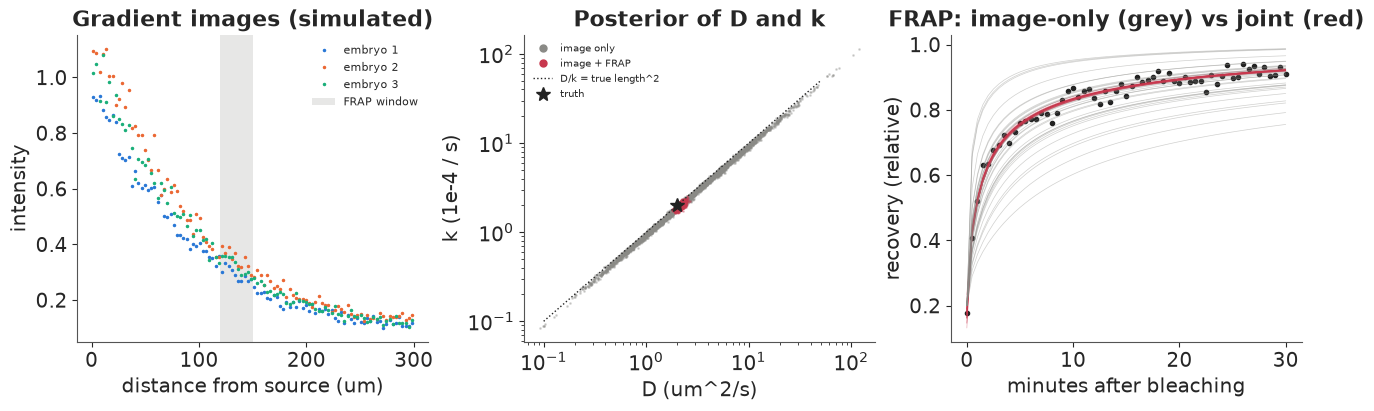

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ax = axes[0]
for i in range(3):
    ax.plot(xs, images[i], ".", ms=3, color=[BLUE, ORANGE, AQUA][i], label=f"embryo {i + 1}")
ax.axvspan(120, 150, color=GREY, alpha=0.2, lw=0, label="FRAP window")
ax.set(xlabel="distance from source (um)", ylabel="intensity", title="Gradient images (simulated)")
ax.legend(fontsize=8)
ax = axes[1]
for label, c in [("image only", GREY), ("image + FRAP", RED)]:
    p = grad_fits[label].posterior
    ax.plot(p["D"].values.ravel(), p["k"].values.ravel() * 1e4, ".", ms=2, alpha=0.3, color=c)
    ax.plot([], [], "o", ms=5, color=c, label=label)
d_line = np.geomspace(0.1, 50, 50)
ax.plot(d_line, d_line / np.sqrt(D_TRUE / K_TRUE) ** 2 * 1e4, ":", color=INK, lw=1, label="D/k = true length^2")
ax.plot(D_TRUE, K_TRUE * 1e4, "*", color=INK, ms=10, label="truth")
ax.set(xscale="log", yscale="log", xlabel="D (um^2/s)", ylabel="k (1e-4 / s)", title="Posterior of D and k")
ax.legend(fontsize=7, loc="upper left")
ax = axes[2]
ax.plot(t_frap / 60, frap_obs, "o", color=INK, ms=3, label="FRAP data")
p = grad_fits["image + FRAP"].posterior
pick = rng.choice(p.sizes["chain"] * p.sizes["draw"], 30, replace=False)
Dd, kd = p["D"].values.ravel()[pick], p["k"].values.ravel()[pick]
fr = p["bleached_fraction"].values.ravel()[pick]
for d_, k_, f_ in zip(Dd, kd, fr):
    ax.plot(t_frap / 60, frap_recovery(d_, k_, t_frap, bleach, f_), color=RED, lw=0.5, alpha=0.4)
p0 = grad_fits["image only"].posterior
for i in rng.choice(p0.sizes["chain"] * p0.sizes["draw"], 30, replace=False):
    ax.plot(t_frap / 60, frap_recovery(p0["D"].values.ravel()[i], p0["k"].values.ravel()[i], t_frap, bleach, 0.8),
            color=GREY, lw=0.5, alpha=0.4)
ax.set(xlabel="minutes after bleaching", ylabel="recovery (relative)",
       title="FRAP: image-only (grey) vs joint (red)");

**The image alone pins down the length, not the mechanism.** Its posterior for the decay
length $\sqrt{D/k}$ is tight around 100 µm, but $D$ and $k$ separately slide along the line
$D/k = \ell^2$ over more than an order of magnitude (middle panel, grey): a fast-diffusing,
quickly cleared morphogen and a slow, stable one make the same steady-state gradient. This
is not a sampling problem (the chains mix well). It is what the data say, and no prior short of
fixing one of the two could fix it.

## 7 · FRAP separates diffusion from degradation

The ridge is easiest to see in time. Switch the source on in an empty field and let the gradient
form: every posterior draw from the image-only fit ends at the same steady shape, but they get
there at very different speeds, because a fast-diffusing, quickly cleared morphogen equilibrates in
minutes and a slow, stable one takes hours. The draws from the joint fit agree on the speed as
well. (Each curve is scaled by its own steady-state maximum, as the images are.)

In [11]:
def forming(D, k, t):
    """c(t) / max(c_ss) after switching the source on at t = 0 in an empty field."""
    rates = D * mu_eig - k
    c_ss = V_eig @ ((V_eig.T @ source) / (-rates))
    c_t = c_ss[None, :] - (np.exp(rates[None, :] * t[:, None]) * (V_eig.T @ c_ss)[None, :]) @ V_eig.T
    return c_t / c_ss.max()


t_form = np.geomspace(60, 12 * 3600, 45)                      # 1 min to 12 h
curves = {}
for label in grad_fits:
    p_ = grad_fits[label].posterior
    idx_ = rng.choice(p_.sizes["chain"] * p_.sizes["draw"], 25, replace=False)
    curves[label] = [forming(p_["D"].values.ravel()[i], p_["k"].values.ravel()[i], t_form) for i in idx_]
truth_form = forming(D_TRUE, K_TRUE, t_form)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72, sharey=True)
lines = {}
for ax, (label, col) in zip(axes, [("image only", GREY), ("image + FRAP", RED)]):
    lines[label] = [ax.plot(xs, c_[0], color=col, lw=0.8, alpha=0.6)[0] for c_ in curves[label]]
    ax.plot(xs, c_true / c_true.max(), ":", color=INK, lw=1, label="steady state (truth)")
    lines[label].append(ax.plot(xs, truth_form[0], color=INK, lw=1.8, label="truth")[0])
    ax.set(xlabel="distance from source (um)", title=f"posterior draws: {label}", ylim=(0, 1.05))
axes[0].set_ylabel("concentration / steady-state max")
axes[0].legend(fontsize=8)
suptitle = fig.suptitle("")
plt.close(fig)


def update(i):
    for label in curves:
        for ln, c_ in zip(lines[label], curves[label]):
            ln.set_ydata(c_[i])
        lines[label][-1].set_ydata(truth_form[i])
    suptitle.set_text(f"{t_form[i] / 60:5.0f} minutes after the source switches on")
    return []


anim = animation.FuncAnimation(fig, update, frames=len(t_form), interval=180)
HTML(anim.to_jshtml(default_mode="once"))


**FRAP breaks the tie.** Bleaching a window and watching it refill measures a *rate*: how
fast unbleached molecules diffuse back in and how fast the pool turns over. The image-only
posterior predicts a whole fan of recovery curves (right panel, grey), and the observed curve
picks out one point on the ridge. The joint posterior recovers $D$ and $k$ to within a few per
cent of the truth. This is how Müller et al. (2012) established that Lefty diffuses much faster
than Nodal, the basis of the activator-inhibitor ("Turing-type") picture of Nodal/Lefty
patterning. The general lesson: **when a steady state identifies only a combination of
parameters, a perturbation experiment that probes dynamics separates them.**

## 8 · Positional information: how well can a cell read the gradient?

A gradient is only useful if cells can read it. Cells sense the morphogen through receptors,
and a simple model of the read-out is **receptor occupancy** $\theta(x) = c(x)/(c(x) + K_d)$,
which drives a downstream signal (for Nodal, phosphorylated Smad2). A cell that reads $\theta$
with noise $\sigma_\theta$ locates itself with **positional error**

$$\sigma_x(x) = \frac{\sigma_\theta(x)}{|d\theta/dx|}.$$

(Gregor et al. 2007 measured about 1% of embryo length for the Bicoid gradient in the fly.) Two
noise sources enter $\sigma_\theta$:

- **ligand noise**: the cell-to-cell variation of the concentration itself, estimated from the
  images (about 5%) and propagated through the receptor,
  $\sigma_\theta = \text{cv}\,\theta(1-\theta)$;
- **receptor counting noise**: a cell has a finite number $N_R$ of receptors, and the fraction
  occupied at any moment is binomial, $\sigma_\theta^2 = \theta(1-\theta)/N_R$. We take
  $N_R = 2{,}000$, a typical order of magnitude for signaling receptors, and assume no time
  averaging.

The first on its own is instructive: since $d\theta/dx = \theta(1-\theta)\,(d\log c/dx)$, the
receptor factor cancels and $\sigma_x = \text{cv}\,/\,|d\log c/dx|$, whatever $K_d$ is. **A
monotone read-out cannot add or remove information that is already lost upstream.** The
receptor matters only through the noise it adds itself. We compute both from the joint
posterior of the gradient and the cell-to-cell variation, for three receptor affinities
(concentration scaled to 1 at the source). A summary of precision is the **number of
distinguishable positions** across the field, $\int dx / (2\sigma_x)$: how many cell states the
gradient could specify if neighbouring states had to be two standard deviations apart.

ligand only        high affinity (Kd = 0.02)  positional error at 50/150/250 um (median):   5.5 /   6.1 /  12.2 um; distinguishable positions 19.7 (90%: 17.6-22.2)
ligand only        Kd = 0.2                   positional error at 50/150/250 um (median):   5.5 /   6.1 /  12.2 um; distinguishable positions 19.7 (90%: 17.6-22.2)
ligand only        low affinity (Kd = 2)      positional error at 50/150/250 um (median):   5.5 /   6.1 /  12.2 um; distinguishable positions 19.7 (90%: 17.6-22.2)
ligand + receptor  high affinity (Kd = 0.02)  positional error at 50/150/250 um (median):  15.1 /  11.9 /  19.8 um; distinguishable positions  9.3 (90%: 8.7-9.9)
ligand + receptor  Kd = 0.2                   positional error at 50/150/250 um (median):   7.9 /   8.0 /  16.2 um; distinguishable positions 14.5 (90%: 13.4-15.5)
ligand + receptor  low affinity (Kd = 2)      positional error at 50/150/250 um (median):   7.7 /  10.1 /  24.8 um; distinguishable positions 12.3 (90%: 11.6-12.9)


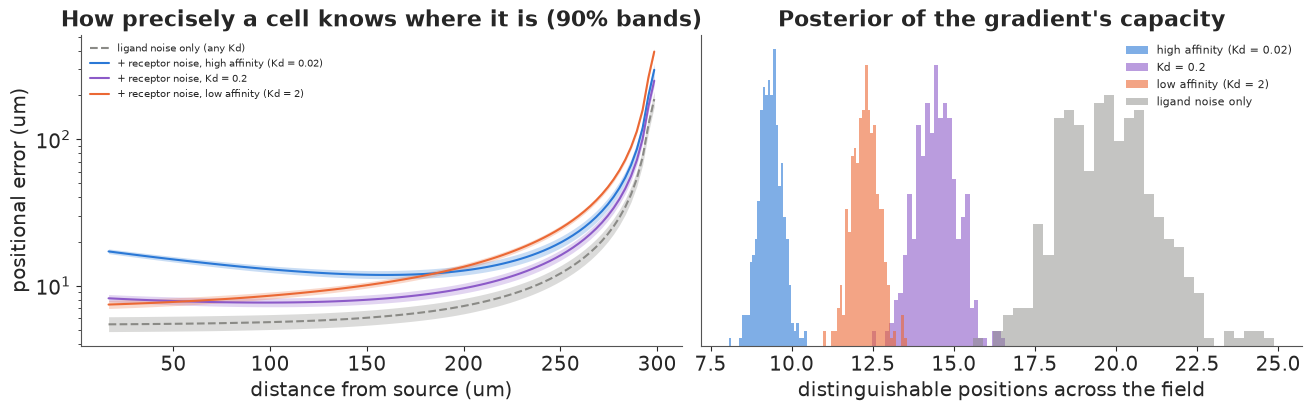

In [12]:
p = grad_fits["image + FRAP"].posterior
n_draws = 400
idx = rng.choice(p.sizes["chain"] * p.sizes["draw"], n_draws, replace=False)
D_d, k_d = p["D"].values.ravel()[idx], p["k"].values.ravel()[idx]
cv_d = p["cv_cell"].values.ravel()[idx]
shapes = np.array([sdd_steady(d_, k_) for d_, k_ in zip(D_d, k_d)])
shapes /= shapes.max(axis=1, keepdims=True)
field = xs > 15                                                 # outside the source
N_RECEPTORS = 2000
kd_levels = {"high affinity (Kd = 0.02)": 0.02, "Kd = 0.2": 0.2, "low affinity (Kd = 2)": 2.0}
pos_err, n_states = {}, {}
for noise in ["ligand only", "ligand + receptor"]:
    for label, kd_ in kd_levels.items():
        theta = shapes / (shapes + kd_)
        dtheta = np.abs(np.gradient(theta, DXS, axis=1))
        var_theta = (cv_d[:, None] * theta * (1 - theta)) ** 2
        if noise == "ligand + receptor":
            var_theta = var_theta + theta * (1 - theta) / N_RECEPTORS
        sig_x = np.sqrt(var_theta) / np.maximum(dtheta, 1e-12)
        pos_err[noise, label] = sig_x
        n_states[noise, label] = (DXS / (2 * sig_x[:, field])).sum(axis=1)
        print(f"{noise:<18} {label:<26} positional error at 50/150/250 um (median): "
              f"{np.median(sig_x[:, 16]):5.1f} / {np.median(sig_x[:, 50]):5.1f} / {np.median(sig_x[:, 83]):5.1f} um; "
              f"distinguishable positions {np.median(n_states[noise, label]):4.1f} "
              f"(90%: {np.quantile(n_states[noise, label], 0.05):.1f}-{np.quantile(n_states[noise, label], 0.95):.1f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
lo, med, hi = np.quantile(pos_err["ligand only", "Kd = 0.2"], [0.05, 0.5, 0.95], axis=0)
ax.fill_between(xs[field], lo[field], hi[field], color=GREY, alpha=0.3, lw=0)
ax.plot(xs[field], med[field], color=GREY, ls="--", label="ligand noise only (any Kd)")
for label, c in zip(kd_levels, [BLUE, PURPLE, ORANGE]):
    lo, med, hi = np.quantile(pos_err["ligand + receptor", label], [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(xs[field], lo[field], hi[field], color=c, alpha=0.25, lw=0)
    ax.plot(xs[field], med[field], color=c, label=f"+ receptor noise, {label}")
ax.set(yscale="log", xlabel="distance from source (um)", ylabel="positional error (um)",
       title="How precisely a cell knows where it is (90% bands)")
ax.legend(fontsize=7)
ax = axes[1]
for label, c in zip(kd_levels, [BLUE, PURPLE, ORANGE]):
    ax.hist(n_states["ligand + receptor", label], bins=30, color=c, alpha=0.6, label=label)
ax.hist(n_states["ligand only", "Kd = 0.2"], bins=30, color=GREY, alpha=0.5, label="ligand noise only")
ax.set(xlabel="distinguishable positions across the field", yticks=[], title="Posterior of the gradient's capacity")
ax.legend(fontsize=8);

With ligand noise alone (grey) every receptor gives the same answer: a positional error of about
$\text{cv} \times \ell \approx 5$ µm over most of the field, rising near the far wall where the
gradient flattens. Receptor counting noise changes that, and **the receptor's affinity now
decides where the gradient can be read**: a cell reads its position best where occupancy is
intermediate, i.e. where the local concentration is near $K_d$. A high-affinity receptor
saturates near the source (its error there is twice the others') and reads the far field better
than a low-affinity receptor, which is sparsely occupied far away and reads the near field as well
as the intermediate one. The numbers of distinguishable positions (printout)
are the gradient's capacity to specify cell states under each assumption; the intermediate
affinity, whose $K_d$ sits inside the range of concentrations the gradient spans, supports the
most. Their posterior
spread is small because image + FRAP pin down the gradient; with the image alone, the length
scale (which is what matters here) is also well determined, so this part of the analysis would
not have needed FRAP - a reminder to ask which parameters a decision actually depends on.

## Summary

- **Reaction-diffusion PDEs fit in PyMC by the method of lines**: finite volumes, no-flux
  boundaries, explicit steps in `scan` with the stability limit checked, and a count likelihood.
  For a linear PDE, the eigenbasis of the discrete Laplacian gives exact, differentiable
  solutions without time stepping (sections 2 and 5).
- **On real scratch-assay data**, a start-up delay improves the fit by a wide LOO margin, and
  leaving it out biases the estimated cell diffusivity about fourfold with confidently narrow
  intervals (section 3).
- **Identify what the experiment can identify**: the invasion speed $2\sqrt{D\lambda}$ is better
  determined than motility and proliferation separately, and capacity and growth rate trade
  off (section 4).
- **A steady-state gradient identifies only its decay length** $\sqrt{D/k}$; a FRAP time course
  separates diffusion from clearance (sections 6-7).
- **Positional information** follows from the posterior of the gradient and the read-out noise.
  Upstream (ligand) noise gives the same positional error through any receptor; receptor counting
  noise makes the affinity decide where the gradient is read best (section 8).

## Try it yourself

1. **Porous-Fisher and noise models.** Replace linear diffusion by density-dependent diffusion
   $\partial_x (D u\, \partial_x u)$ (the "porous Fisher" model, which gives sharp fronts), and
   the Poisson likelihood by a binomial with the capacity as a parameter. Compare by LOO. Which
   conclusions about $D$ and $\lambda$ survive?
2. **Averaging.** Real cells integrate their receptors over time (a correlation time
   $\tau_c$, dividing the counting variance by roughly $T/\tau_c$ for an integration time $T$) and
   over neighbours. Add both to section 8. Which receptor affinity now maximises the number of
   distinguishable positions, and how long must a cell integrate to reach the ligand-noise limit?
3. **A Turing pair.** Add a second, faster-diffusing inhibitor (Lefty-like, $D \approx 15$
   µm²/s) that is induced by the activator and blocks it, and simulate the two-species
   activator-inhibitor system. Derive the linear-stability (Turing) condition, then compute the
   posterior probability that it holds when both species' $D$ and $k$ are estimated from FRAP data
   with realistic noise.